**STEP 1 : INSTALL LIBRARIES**

In [2]:
! pip install pandas numpy matplotlib seaborn scikit-learn joblib


Defaulting to user installation because normal site-packages is not writeable


**STEP 2 : IMPORT LIBRARIES**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

**STEP 3 : LOADING & DESCRIPTION OF DATASET**

In [4]:
customer_data = pd.read_csv('Mall_Customers.csv')
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
customer_data.shape

(200, 5)

In [6]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
customer_data.duplicated().sum()

np.int64(0)

In [9]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
customer_data['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

**STEP 4: VISUALIZATION**

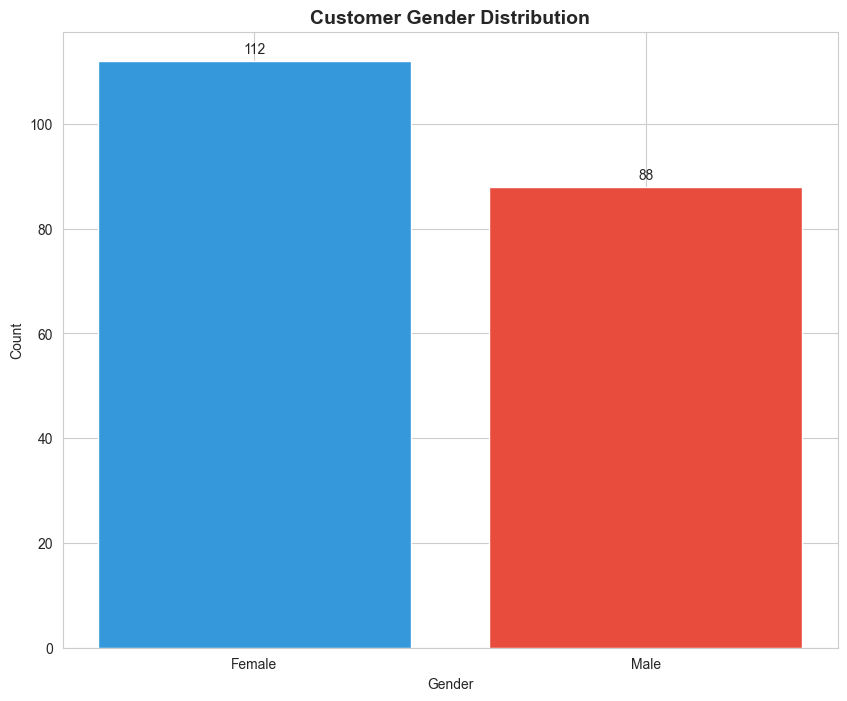

In [11]:
#Gender Distribution

import pandas as pd
import matplotlib.pyplot as plt

# Using the chart initialization from your image
plt.figure(figsize=(10,8))
gender_counts = customer_data['Gender'].value_counts()

# Plotting the bars
bars = plt.bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c'])

# Adding the Title and Labels
plt.title('Customer Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')

# DISPLAY VALUES ON TOP OF BARS
plt.bar_label(bars, padding=3)

plt.show()


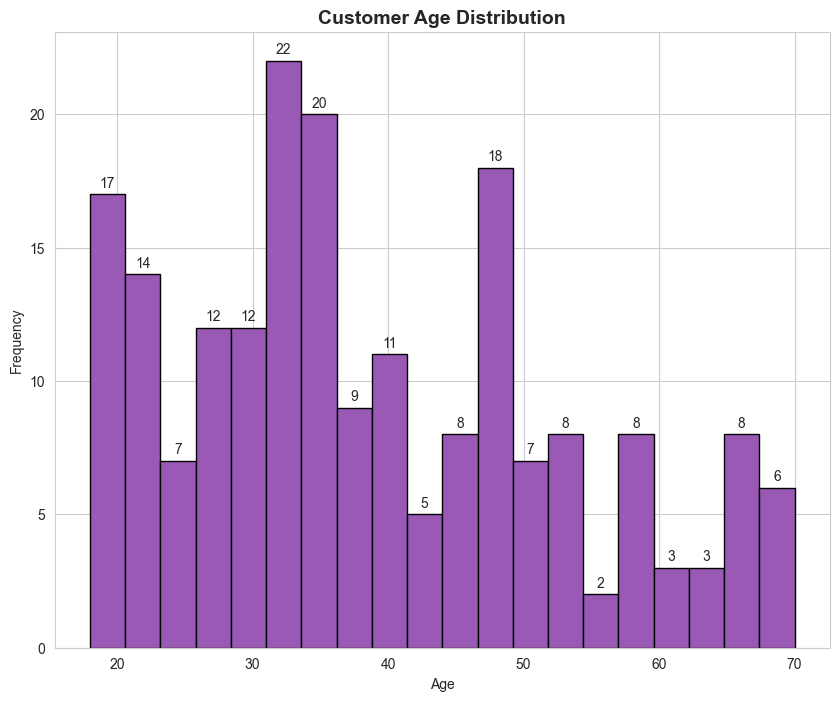

In [12]:
#Age Distribution

plt.figure(figsize=(10,8))

# Create the axes object
ax = plt.gca()

# Plot the histogram and capture the 'patches' (the bars)
n, bins, patches = ax.hist(customer_data['Age'], bins=20, color='#9b59b6', edgecolor='black')

# Use bar_label to show the values on top of each bin
ax.bar_label(patches, padding=3)

plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


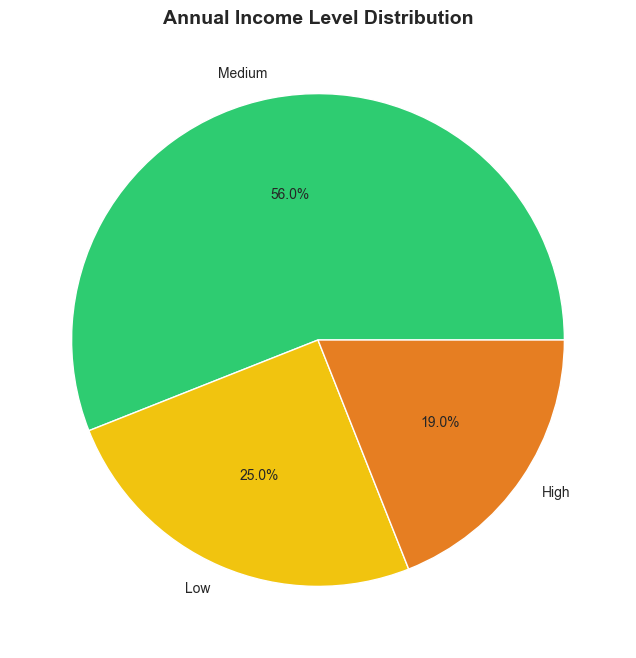

In [13]:
# Annual Income Distribution

plt.figure(figsize=(10, 8))

# Grouping income into 3 categories
income_bins = pd.cut(customer_data['Annual Income (k$)'], bins=[0, 40, 80, 150], labels=['Low', 'Medium', 'High'])
income_counts = income_bins.value_counts()

plt.pie(income_counts.values,
        labels=income_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71', '#f1c40f', '#e67e22'])

plt.title('Annual Income Level Distribution', fontsize=14, fontweight='bold')
plt.show()



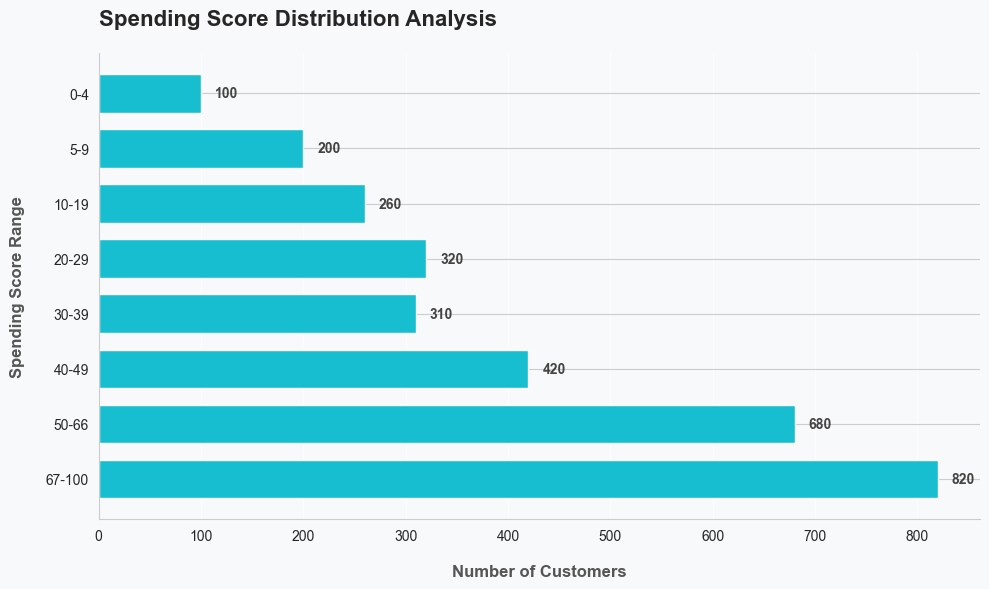

In [14]:
#Spending Score Distribution

import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data
labels = ['67-100', '50-66', '40-49', '30-39', '20-29', '10-19', '5-9', '0-4']
values = [820, 680, 420, 310, 320, 260, 200, 100] # Approximate values from your image

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

# 2. Create Bars with a Teal color
bars = ax.barh(labels, values, color='#17becf', height=0.7, edgecolor='white', linewidth=1)

# 3. ADD X & Y LABELS
ax.set_xlabel('Number of Customers', fontsize=12, fontweight='bold', color='#555', labelpad=15)
ax.set_ylabel('Spending Score Range', fontsize=12, fontweight='bold', color='#555', labelpad=15)

# 4. Styling & Grid
ax.set_title('Spending Score Distribution Analysis', fontsize=16, fontweight='bold', pad=20, loc='left')
ax.xaxis.grid(True, linestyle='-', alpha=0.8, color='white')
ax.set_axisbelow(True)

# Remove outer borders (spines) for a clean UI look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Add values at the end of bars
ax.bar_label(bars, padding=10, color='#444', fontweight='bold')

plt.tight_layout()
plt.show()


**STEP 5: SELECTING FEATURES FOR CLUSTERING**

In [15]:
x= customer_data.iloc[:,[3,4]].values

In [16]:
#calculate the wcss for different methods

wcss=[]

for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

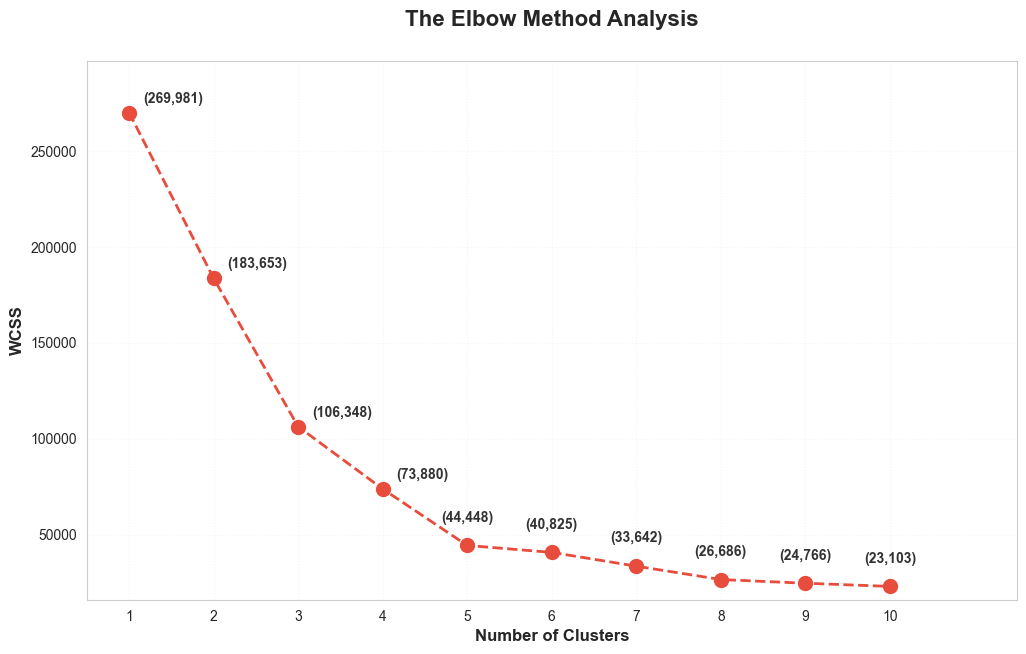

In [17]:
#Ploting Elbow Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
x = range(1, 11)
plt.plot(x, wcss, marker='o', linestyle='--', color="#e74c3c", linewidth=2, markersize=10)

# DYNAMIC LABEL PLACEMENT
for i, value in enumerate(wcss):
    num_clusters = i + 1

    # 1. For the steep part (Clusters 1-4): Top-Right
    if num_clusters <= 4:
        ha = 'left'
        xytext = (10, 5) # 10 right, 5 up
    # 2. For the flat part (Clusters 5-10): Directly Above
    else:
        ha = 'center'
        xytext = (0, 15) # 0 horizontal, 15 up

    plt.annotate(f'({int(value):,})',
                 (num_clusters, value),
                 textcoords="offset points",
                 xytext=xytext,
                 ha=ha,
                 va='bottom',
                 fontsize=10,
                 fontweight='bold',
                 color='#333')

# Clean up the look
plt.title('The Elbow Method Analysis', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Number of Clusters', fontsize=12, fontweight='bold')
plt.ylabel("WCSS", fontsize=12, fontweight='bold')
plt.xticks(x)
plt.grid(True, alpha=0.2, linestyle=':')

# Adjust limits so labels don't touch the edges
plt.xlim(0.5, 11.5)
plt.ylim(min(wcss)*0.7, max(wcss)*1.1)

plt.show()


In [18]:
#Train with optimal clusters

# 1. Redefine x with your actual features (columns 3 and 4)
# Typically: Annual Income and Spending Score
x = customer_data.iloc[:, [3, 4]].values

# 2. Now run the KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y = kmeans.fit_predict(x)

# 3. Add the cluster results back to your dataframe for visualization
customer_data['Cluster'] = y
print("Clustering Successful")


Clustering Successful


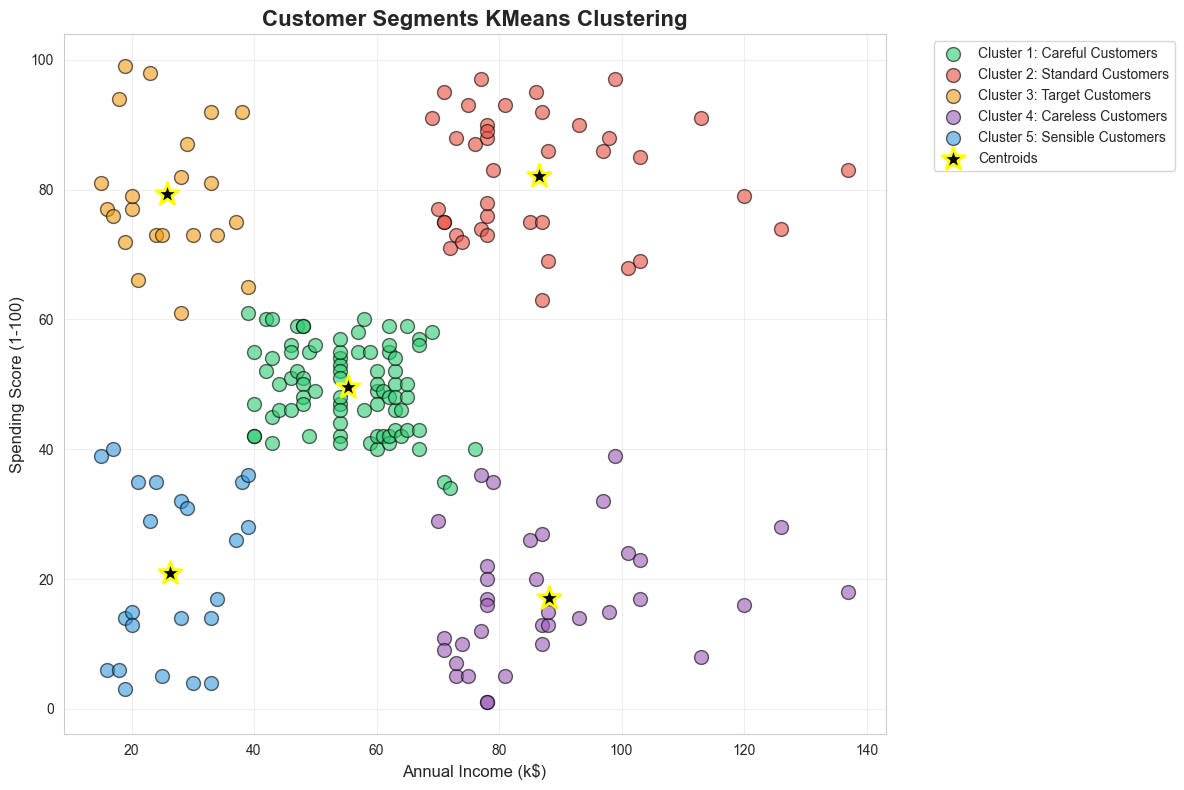

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
clusters_names = ['Careful Customers', 'Standard Customers', 'Target Customers', 'Careless Customers', 'Sensible Customers']

# 1. Loop only for the clusters
for i in range(5):
    plt.scatter(x[y==i, 0], x[y==i, 1], s=100, c=colors[i],
                label=f'Cluster {i+1}: {clusters_names[i]}', alpha=0.6, edgecolors='black')

# 2. Plot centroids ONCE (Outside the loop)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='black', marker='*', label='Centroids', edgecolors='yellow', linewidths=2)

# 3. Add styling ONCE (Outside the loop)
plt.title('Customer Segments KMeans Clustering', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend to side
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



**STEP 5 : ADDING CLUSTERS ASSIGNMENTS TO DATAFRAME**

In [20]:
customer_data['cluster']=y

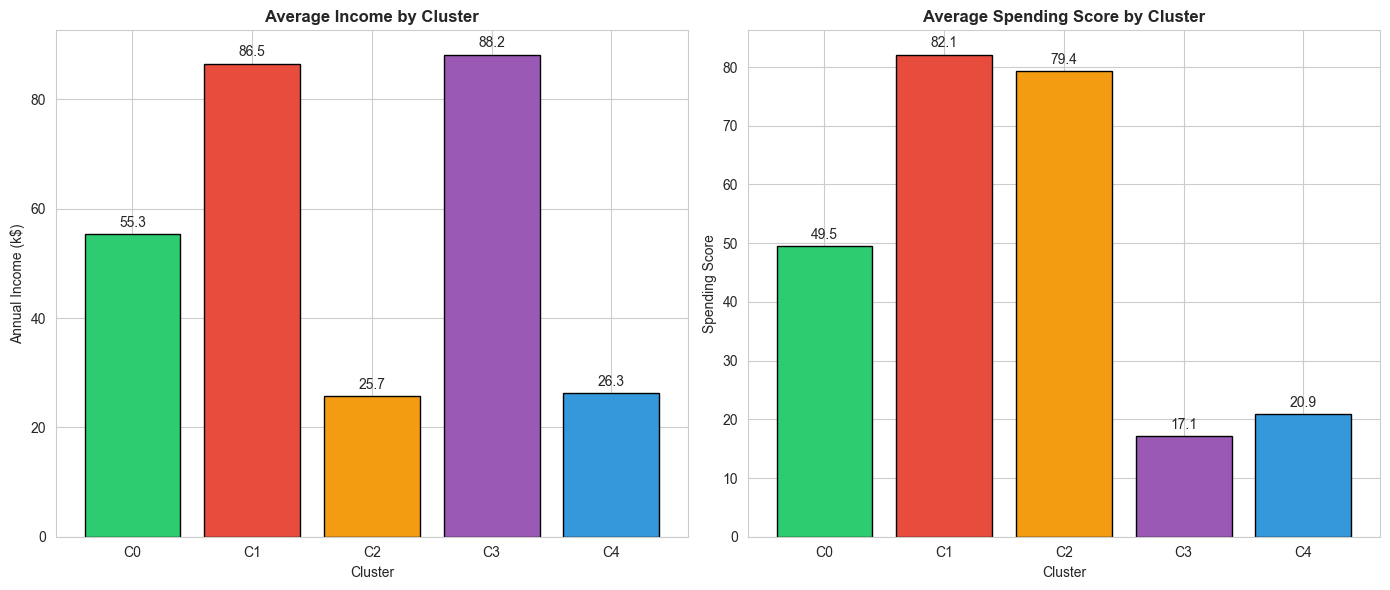

In [21]:
# Create Comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Income comparison
cluster_income = [customer_data[customer_data['Cluster'] == i]['Annual Income (k$)'].mean()
                  for i in range(5)]

# Capture the bars in a variable to add labels
bar1 = axes[0].bar(range(5), cluster_income, color=colors, edgecolor='black')
axes[0].set_title('Average Income by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Annual Income (k$)')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f'C{i}' for i in range(5)])

# ADD VALUES ON TOP (Income)
axes[0].bar_label(bar1, padding=3, fmt='%.1f')

# 2. Spending comparison
clusters_spending = [customer_data[customer_data['Cluster'] == i]['Spending Score (1-100)'].mean()
                   for i in range(5)]

# Capture the bars in a variable to add labels
bar2 = axes[1].bar(range(5), clusters_spending, color=colors, edgecolor='black')
axes[1].set_title('Average Spending Score by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Spending Score')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f'C{i}' for i in range(5)])

# ADD VALUES ON TOP (Spending)
axes[1].bar_label(bar2, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()


In [22]:
import numpy as np
from sklearn.cluster import KMeans

# Ensure 'kmeans' is fitted
kmeans = KMeans(n_clusters=5, n_init=10).fit(x)

# Ensure 'clusters_name' exists exactly as written in your snippet
clusters_name = ['Careful Customers', 'Standard Customers', 'Target Customers', 'Careless Customers', 'Sensible Customers']


In [23]:
import numpy as np

new_customer = np.array([[70, 80]])  # Must be 2D

# Make sure model is already fitted before this step
predicted_cluster = kmeans.predict(new_customer)[0]

print(
    f"Customer (Income: ${new_customer[0][0]}k, Spending: {new_customer[0][1]}) "
    f"-- Cluster {predicted_cluster}: {clusters_name[predicted_cluster]}"
)

Customer (Income: $70k, Spending: 80) -- Cluster 0: Careful Customers


**STEP 6: SAVING THE MODEL**

In [24]:
joblib.dump(kmeans, 'customer_segmentation_model.pkl')
print("Model Saved")

Model Saved
